# Selection and target response

Read saved results, inspect the numbers, draw figures, and export a new snapshot.
This notebook runs independently of the other notebooks.
`OWNED_TABLES` below lists the CSVs exported here; figure names appear in
the drawing cells.

**Inputs:** HP curves/selection and all saved run summaries, monitors, entropy, and silhouette. No training, additional network inference, or UMAP runs here.
**Use:** run from the top once. For presentation edits, rerun only that chapter's
display-settings and drawing cells. For changes to inputs or display targets,
restart the kernel and run all cells so that every chapter uses the same conditions.
Save the notebook file before exporting to include your code in the source copy.

## 1. Settings

Shared defaults are in `figure_settings.py`; the next cell reloads them.
`DISPLAY_TARGETS=None` selects the lowest seed-median final classifier validation
loss for each model. Ties within absolute 1e-6 (relative tolerance zero) choose
the smaller target. A model dictionary changes the display only; HP eta selection
remains unchanged. PDF is OFF by default. Viewing creates no files.

In [1]:
from pathlib import Path
import sys
import json
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "experiment_settings.py").is_file()
    and (p / "src/hnn2").is_dir()
)

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "notebooks"))

import figure_settings

defaults = importlib.reload(figure_settings)

from hnn2.figure_tables import (
    KEYS,
    _identity,
    load_figure_runs,
    require_complete,
    analysis_target_tables,
    check_figure_inputs,
    selected_runs,
    save_figure_tables,
)
from hnn2.hp.select import eta_table, landscape_table
from hnn2.targets import _argmax_table, TIEBREAK_RULE
from hnn2.plots import MODEL_COLORS
from hnn2.figure_plots import _points, _arm_label, save_basic_figures


In [2]:
RESULTS = Path(defaults.RESULTS_ROOT)
OUTPUT = Path(defaults.OUTPUT)

DISPLAY_TARGETS = defaults.DISPLAY_TARGETS

SAVE_NUMBERS = defaults.SAVE_NUMBERS
SAVE_PNG = defaults.SAVE_PNG
SAVE_PDF = defaults.SAVE_PDF  # False by default; enable explicitly when needed.
SHOW_FIGURES = defaults.SHOW_FIGURES
EXPORT_NAME = defaults.EXPORT_NAME

NOTEBOOK_OWNER = "selection"
NOTEBOOK_PATH = ROOT / "notebooks" / "01_selection.ipynb"

OWNED_TABLES = [
    "hp_curves",
    "hp_landscape",
    "hp_selected",
    "hp_used_eta",
    "target_evidence",
    "target_statistics",
    "target_candidate_evidence",
    "target_diagnostic_candidates",
    "analysis_targets",
    "conditions",
    "coverage",
]

## 2. Load and check results

All five result notebooks require the complete saved run artifacts, planned
run lists, HP selection, and recorded dataset files, even when a chapter uses
only some of those inputs. The coverage table includes every planned run,
including missing or invalid runs. The notebook stops on incomplete data.

Source hashes, HP eta, scientific conditions, budgets, and seed populations
are checked before comparisons. Effective targets and displayed seeds below
are the conditions for this kernel.

In [3]:
selection_directory = RESULTS / "hp/selection"
runs, expected = load_figure_runs(RESULTS)
display(expected.groupby(["arm", "state"], dropna=False).size().rename("runs").reset_index())
display(expected.loc[expected.state != "complete", ["run", "state", "reason"]])
require_complete(expected)

# Assemble all targets before applying the shared display-selection rule.
parts = []
for path, (conditions, arrays, saved) in runs.items():
    frame = saved["summary"].assign(**_identity(path, conditions))
    frame["n_readout_parameters"] = (frame.n_features + 1) * frame.n_classes
    frame["final_model"] = "last_step; best_val_accuracy is monitoring_only"
    frame["readout_eval_every"] = conditions["config"]["readout_eval_every"]
    frame["readout_epochs"] = conditions["config"]["readout_epochs"]
    parts.append(frame)
summary = pd.concat(parts, ignore_index=True)
candidates, effective = analysis_target_tables(summary, DISPLAY_TARGETS)
targets = effective.set_index("model_code").targ.to_dict()
report, coverage = check_figure_inputs(runs, expected, selection_directory, targets)
selected = selected_runs(runs, targets)
chosen_paths = set(selected)
chosen = summary[summary.run.isin(chosen_paths)].reset_index(drop=True)
models = [model for model in ("rec", "ff", "thresh") if model in targets]
arms = [f"{model}_{stage}" for model in models for stage in ("initial", "trained")] + ["raw", "mlp_frozen"]
arm_labels = [_arm_label(arm, targets) for arm in arms]
tables = {"summary": summary, "selected_summary": chosen}
figures = {}
display(effective)
display(chosen.groupby("arm").seed_index.agg(list).rename("displayed_seeds").to_frame())
print(f"Input: {RESULTS.resolve()}\nOutput: {OUTPUT.resolve()}")
print("Invalid or missing planned runs:", int(coverage.state.ne("complete").sum()))

,arm,state,runs
0,ff_initial,complete,3
1,ff_trained,complete,27
2,mlp_frozen,complete,3
3,raw,complete,3
4,rec_initial,complete,3
5,rec_trained,complete,27
6,thresh_initial,complete,3
7,thresh_trained,complete,27


,run,state,reason


,model_code,targ,method,median_final_val_loss,tiebreak
0,ff,0.55,median_final_val_loss,0.449672,absolute difference <= 1e-06 from the best see...
1,rec,0.17,median_final_val_loss,0.368852,absolute difference <= 1e-06 from the best see...
2,thresh,1.55,median_final_val_loss,0.649693,absolute difference <= 1e-06 from the best see...


,displayed_seeds
arm,
ff_initial,"[0, 1, 2]"
ff_trained,"[0, 1, 2]"
mlp_frozen,"[0, 1, 2]"
raw,"[0, 1, 2]"
rec_initial,"[0, 1, 2]"
rec_trained,"[0, 1, 2]"
thresh_initial,"[0, 1, 2]"
thresh_trained,"[0, 1, 2]"


Input: outputs\synthetic_long_v1\results
Output: outputs\synthetic_long_v1\analysis\notebook_figures_v2
Invalid or missing planned runs: 0


### Statistics used in this notebook

Grouping columns are stated at each call below. This small local helper keeps
every finite seed, counts missing/nonfinite values, uses population SD (`ddof=0`),
and uses linear quartiles. Undefined values stay undefined.

In [4]:
def describe_values(frame, groups, columns):
    """Explicit finite n and missing n; SD is population SD (ddof=0)."""
    rows = []
    for coords, g in frame.groupby(groups, dropna=False, sort=True):
        coords = coords if isinstance(coords, tuple) else (coords,)
        identity = dict(zip(groups, coords))
        for key in columns:
            values = g[key].to_numpy(float)
            finite = values[np.isfinite(values)]
            rows.append({**identity, "metric": key, "expected_n": len(values), "n": len(finite),
                         "missing_or_invalid": len(values) - len(finite),
                         "mean": finite.mean() if len(finite) else np.nan,
                         "sd": finite.std(ddof=0) if len(finite) else np.nan,
                         "median": np.median(finite) if len(finite) else np.nan,
                         "q1": np.quantile(finite, .25) if len(finite) else np.nan,
                         "q3": np.quantile(finite, .75) if len(finite) else np.nan,
                         "min": finite.min() if len(finite) else np.nan,
                         "max": finite.max() if len(finite) else np.nan})
    return pd.DataFrame(rows)

### Export helper

Chapter saves are opt-in at the end of each chapter. The final export saves
the CSVs listed in `OWNED_TABLES` and the prepared main-chapter figures.
Each save uses a **new name** under `OUTPUT / NOTEBOOK_OWNER`; existing
folders are rejected. Change the name after editing a figure.

PNG and PDF use the switches above. Numeric tables and source records are
saved even if both image switches are OFF.

In [5]:
def export_section(name, figure_names, table_names):
    """Save this chapter to a new directory with its numeric sources."""
    if Path(name).name != name or name in ("", ".", ".."):
        raise ValueError("Use a simple new export name, without directories")
    if not set(table_names) <= set(OWNED_TABLES):
        raise ValueError("Only this notebook's tables may be exported")
    destination = OUTPUT / NOTEBOOK_OWNER / name
    if destination.exists():
        raise FileExistsError(f"Choose a new export name: {destination}")
    # Resolve selections before creating files, so a missing chapter fails early.
    numeric = {key: tables[key] for key in table_names}
    images = {key: figures[key] for key in figure_names}
    numeric_path = save_figure_tables(
        destination / "tables/figures", numeric, runs, targets=targets,
        selection_directory=selection_directory, notebook_path=NOTEBOOK_PATH,
        coverage=coverage, analysis_targets=effective,
    )
    settings = {"results": str(RESULTS.resolve()), "output": str(OUTPUT.resolve()),
                "display_targets": DISPLAY_TARGETS, "effective_targets": targets,
                "png": SAVE_PNG, "pdf": SAVE_PDF, "export_name": name,
                "figures": list(images), "tables": list(numeric)}
    (numeric_path / "notebook_settings.json").write_text(
        json.dumps(settings, indent=2), encoding="utf-8")
    save_basic_figures(images, destination / "figures", png=SAVE_PNG,
                       pdf=SAVE_PDF, numeric_source=numeric_path)
    print(f"Saved: {destination}")
    return destination

## 3. HP eta selection

The stored HP rule and selected eta are read unchanged. Crosses mark unstable candidates; circles mark selected eta.

In [6]:
tables["hp_curves"] = pd.read_csv(Path(selection_directory) / "curves.csv", float_precision="round_trip")
tables["hp_landscape"] = landscape_table(report)
# Normalize the displayed scores across targets; retain the saved eta selections.
tables["hp_landscape"]["score_over_targ_squared"] = tables["hp_landscape"].score / tables["hp_landscape"].targ**2
tables["hp_selected"] = eta_table(report).assign(at_epoch=report["rule"]["at_epoch"],
                                              stability_epochs=report["rule"]["stability_epochs"],
                                              stability_tol=report["rule"]["stability_tol"])
tables["coverage"] = coverage

In [7]:
for name in ['hp_selected', 'hp_landscape', 'hp_curves']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

hp_selected: 27 rows (preview below; export keeps every row)


,model_code,targ,eta,score,fluctuation,stable,n_candidates,boundary,boundary_side,reason,...,filter_changed,rate_mean,rate_wmean,residual,residual_train,grid_min,grid_max,at_epoch,stability_epochs,stability_tol
0,ff,0.17,0.0003,0.000985,-0.069486,True,11,False,,argmin_stable,...,False,0.188360,0.180897,0.064099,0.017543,0.000001,30.0,7,2,0.5
1,ff,0.20,0.0003,0.001198,-0.077230,True,16,False,,argmin_stable,...,False,0.218213,0.212242,0.061209,0.018067,0.000001,30.0,7,2,0.5
2,ff,0.27,0.0001,0.001110,-0.022283,True,16,False,,argmin_stable,...,False,0.282181,0.280605,0.039277,0.004031,0.000001,30.0,7,2,0.5
3,ff,0.35,0.0001,0.001372,-0.058308,True,16,False,,argmin_stable,...,False,0.358749,0.363967,0.039907,0.010609,0.000001,30.0,7,2,0.5
4,ff,0.55,0.0001,0.002101,-0.140746,True,16,False,,argmin_stable,...,False,0.542630,0.568233,0.033151,0.012485,0.000001,30.0,7,2,0.5
5,ff,0.90,0.0001,0.004512,0.000647,True,16,False,,argmin_stable,...,False,0.858416,0.924399,0.027111,0.011810,0.000001,30.0,7,2,0.5
6,ff,1.15,0.0001,0.007521,0.086936,True,16,False,,argmin_stable,...,False,1.082917,1.178438,0.024729,0.011138,0.000001,30.0,7,2,0.5
7,ff,1.40,0.0001,0.011699,0.137269,True,16,False,,argmin_stable,...,False,1.307365,1.432268,0.023048,0.010668,0.000001,30.0,7,2,0.5
8,ff,1.55,0.0001,0.014782,0.156467,True,16,False,,argmin_stable,...,False,1.442092,1.584529,0.022277,0.010466,0.000001,30.0,7,2,0.5
9,rec,0.17,0.0010,0.000341,-0.098449,True,16,False,,argmin_stable,...,False,0.176278,0.195097,0.147629,0.136635,0.000001,30.0,7,2,0.5


hp_landscape: 432 rows (preview below; export keeps every row)


,model_code,targ,eta,score,score_std,fluctuation,stable,selected,rate_mean,rate_wmean,residual,residual_train,score_over_targ_squared
0,ff,0.17,0.000001,0.028863,0.000050,-0.000007,True,False,0.000114,0.000052,0.999694,0.999671,0.998737
1,ff,0.17,0.000003,0.028859,0.000055,-0.000023,True,False,0.000127,0.000059,0.999655,0.999631,0.998595
2,ff,0.17,0.000010,0.028841,0.000078,-0.000126,True,False,0.000187,0.000090,0.999470,0.999439,0.997942
3,ff,0.17,0.000030,0.028682,0.000217,-0.002118,True,False,0.000698,0.000389,0.997710,0.997636,0.992466
4,ff,0.17,0.000100,0.003916,0.002087,-0.551069,True,False,0.135434,0.126402,0.256458,0.292497,0.135518
5,ff,0.17,0.000300,0.000985,0.000801,-0.069486,True,True,0.188360,0.180897,0.064099,0.017543,0.034069
6,ff,0.17,0.001000,0.002027,0.001343,-0.134747,True,False,0.183711,0.175922,0.034837,0.011872,0.070146
7,ff,0.17,0.003000,0.012471,0.004757,0.053668,True,False,0.148573,0.142685,0.160677,0.189690,0.431510
8,ff,0.17,0.010000,0.166095,0.011056,0.331492,True,False,0.139573,0.150463,0.114925,0.126638,5.747239
9,ff,0.17,0.030000,0.389634,0.113542,0.217820,True,False,0.147640,0.164235,0.033911,0.043769,13.482149


hp_curves: 19440 rows (preview below; export keeps every row)


,arm,model_code,targ,eta,seed_index,l_mean,rate_var,composite,rate_mean,rate_wmean,rate_mean_train,rate_wmean_train,epoch,eta_epoch
0,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.566635e-09,0.028899,0.000002,6.120405e-07,0.000001,3.878781e-07,0,1.000000e-06
1,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.621710e-09,0.028899,0.000002,6.290260e-07,0.000001,4.004683e-07,1,1.000000e-06
2,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.677819e-09,0.028899,0.000002,6.460130e-07,0.000001,4.134458e-07,2,1.000000e-06
3,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.734956e-09,0.028899,0.000002,6.630005e-07,0.000001,4.273854e-07,3,1.000000e-06
4,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.790185e-09,0.028899,0.000002,6.791365e-07,0.000001,4.406268e-07,4,9.500000e-07
5,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.843508e-09,0.028899,0.000002,6.944653e-07,0.000001,4.532051e-07,5,9.025000e-07
6,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.894946e-09,0.028899,0.000002,7.090286e-07,0.000001,4.651556e-07,6,8.573750e-07
7,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.944519e-09,0.028899,0.000002,7.228652e-07,0.000001,4.765097e-07,7,8.145062e-07
8,d0.95_s3,ff,0.17,0.000001,0,0.028899,1.992251e-09,0.028899,0.000002,7.360104e-07,0.000001,4.872969e-07,8,7.737809e-07
9,d0.95_s3,ff,0.17,0.000001,0,0.028899,2.038153e-09,0.028899,0.000002,7.484964e-07,0.000002,4.975425e-07,9,7.350919e-07


### Eta landscape

Edit size and optional axis limits below; the drawing cell reuses the
prepared numbers. Eta curves use Matplotlib's default colors, with black
selected-eta circles and red unstable-candidate crosses set in the drawing cell.

In [8]:
FIGSIZE = (5*len(models), 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

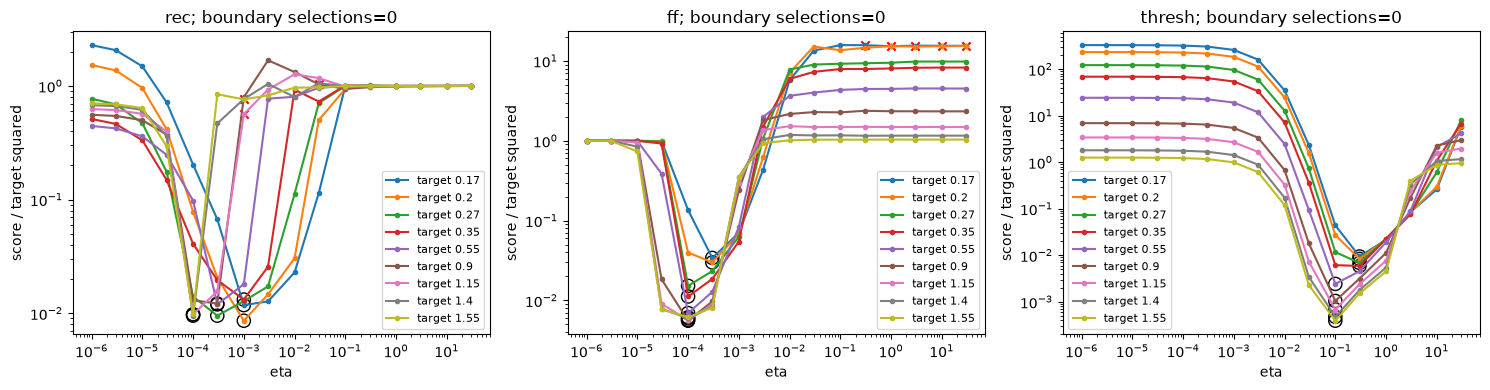

In [9]:
fig, axs = plt.subplots(1, len(models), figsize=FIGSIZE, squeeze=False)
for ax, model in zip(axs[0], models):
    data = tables["hp_landscape"]
    for targ, g in data[data.model_code == model].groupby("targ"):
        g = g.sort_values("eta")
        ax.plot(g.eta, g.score_over_targ_squared, marker=".", label=f"target {targ:g}")
        ax.scatter(g.loc[g.selected, "eta"], g.loc[g.selected, "score_over_targ_squared"], marker="o", s=90, facecolors="none", edgecolors="black")
        ax.scatter(g.loc[~g.stable, "eta"], g.loc[~g.stable, "score_over_targ_squared"], marker="x", color="red")
    selected_eta = tables["hp_selected"]
    boundary = selected_eta[(selected_eta.model_code == model) & selected_eta.boundary]
    ax.set(title=f"{model}; boundary selections={len(boundary)}", xlabel="eta", ylabel="score / target squared", xscale="log")
    ax.legend(fontsize=8)
figures["G1_eta_landscape"] = fig
for ax in axs[0]:
    ax.set_yscale("log")

figures['G1_eta_landscape'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [10]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'eta_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G1_eta_landscape'], ['hp_curves', 'hp_landscape', 'hp_selected'])

## 4. Target evidence

Automatic target selection uses the seed-median final classifier validation
loss. `DISPLAY_TARGETS` can override the displayed targets. Composite,
validation accuracy, and silhouette candidates are retained as diagnostics.

In [11]:
parts = []
for path, (conditions, arrays, saved) in runs.items():
    if "monitor" not in saved:
        continue
    identity = _identity(path, conditions)
    frame = saved["monitor"].assign(**identity)
    frame["monitor_split"] = conditions["config"]["monitor_probe_split"]
    # Target-relative errors use both rate averages on monitor and train splits.
    for suffix in ("", "_train"):
        for kind in ("mean", "wmean"):
            frame[f"residual_{kind}{suffix}"] = abs(frame[f"rate_{kind}{suffix}"] - identity["targ"]) / identity["targ"]
    parts.append(frame)
tables["monitor"] = pd.concat(parts, ignore_index=True)

In [12]:
parts = [saved["silhouette"].assign(**_identity(path, conditions))
         for path, (conditions, arrays, saved) in runs.items() if "silhouette" in saved]
tables["silhouette"] = pd.concat(parts, ignore_index=True)

In [13]:
# Align final adaptation diagnostics with each run's classifier and silhouette.
last = tables["monitor"].sort_values("epoch").groupby("run", as_index=False).tail(1)
evidence = tables["summary"][tables["summary"].arm.str.endswith("_trained")].merge(
    last[["run", "epoch", "composite"]], on="run", validate="one_to_one").merge(
    tables["silhouette"][["run", "silhouette"]], on="run", validate="one_to_one")
# Keep target comparisons paired over the same seeds used for HP selection.
seed_sets = evidence.groupby(["model_code", "targ"]).seed_index.apply(lambda s: tuple(sorted(s)))
if len(set(seed_sets)) != 1:
    raise ValueError("Target comparisons require identical seed sets")
hp_seeds = set(expected.loc[expected.representation == "sparse_trained", "seed_index"])
if set(evidence.seed_index) != hp_seeds:
    raise ValueError("HP and training seed sets differ")
tables["target_evidence"] = evidence
tables["target_statistics"] = describe_values(evidence, ["model_code", "targ"], ["final_val_loss", "composite", "final_val_accuracy", "silhouette"])
tables["target_candidate_evidence"] = candidates
tables["analysis_targets"] = effective

In [14]:
diagnostics = []
for metric, maximize in (("composite", False), ("final_val_accuracy", True), ("silhouette", True)):
    for model, g in evidence.groupby("model_code"):
        if not np.isfinite(g[metric]).all():
            diagnostics.append({"model_code": model, "criterion": metric, "candidate_targ": np.nan,
                                "reason": "missing_or_undefined_metric", "adoption": "not_performed"})
            continue
        value = _argmax_table(g, metric, maximize=maximize)[model]
        diagnostics.append({"model_code": model, "criterion": metric, "candidate_targ": value["chosen_targ"],
                            "value": value["value"], "boundary": value["boundary"],
                            "reason": "diagnostic_only", "adoption": "not_performed"})
tables["target_diagnostic_candidates"] = pd.DataFrame(diagnostics).assign(tiebreak=TIEBREAK_RULE)
tables["hp_used_eta"] = evidence[KEYS].rename(columns={"eta": "used_eta"}).merge(
    tables["hp_selected"][["model_code", "targ", "eta"]].rename(columns={"eta": "selected_eta"}),
    on=["model_code", "targ"], validate="many_to_one")

In [15]:
# Collect input identity and settings for export with the comparison tables.
rows = []
for path, (conditions, arrays, saved) in runs.items():
    rows.append({**_identity(path, conditions), "input_sha256": conditions["input"]["sha256"],
                 "device": conditions["device"], "config": json.dumps(conditions["config"], sort_keys=True),
                 "analysis": json.dumps(conditions["analysis"], sort_keys=True),
                 "mlp": json.dumps(conditions.get("mlp")), "output_version": conditions.get("output_version"),
                 "engine": conditions.get("engine", "single"), "batch_runs": conditions.get("batch_runs", 1)})
tables["conditions"] = pd.DataFrame(rows)

In [16]:
for name in ['target_candidate_evidence', 'analysis_targets', 'target_statistics', 'target_diagnostic_candidates', 'hp_used_eta', 'conditions', 'coverage']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

target_candidate_evidence: 3 rows (preview below; export keeps every row)


,model_code,candidate_targ,median_final_val_loss,boundary,n_seeds,criterion,tiebreak,adoption
0,ff,0.55,0.449672,False,3,median_final_val_loss,absolute difference <= 1e-06 from the best see...,not_performed
1,rec,0.17,0.368852,True,3,median_final_val_loss,absolute difference <= 1e-06 from the best see...,not_performed
2,thresh,1.55,0.649693,True,3,median_final_val_loss,absolute difference <= 1e-06 from the best see...,not_performed


analysis_targets: 3 rows (preview below; export keeps every row)


,model_code,targ,method,median_final_val_loss,tiebreak
0,ff,0.55,median_final_val_loss,0.449672,absolute difference <= 1e-06 from the best see...
1,rec,0.17,median_final_val_loss,0.368852,absolute difference <= 1e-06 from the best see...
2,thresh,1.55,median_final_val_loss,0.649693,absolute difference <= 1e-06 from the best see...


target_statistics: 108 rows (preview below; export keeps every row)


...

,run,arm,model_code,targ,used_eta,seed_index,selected_eta
0,[local path],ff_trained,ff,0.17,0.0003,0,0.0003
1,[local path],ff_trained,ff,0.17,0.0003,1,0.0003
2,[local path],ff_trained,ff,0.17,0.0003,2,0.0003
3,[local path],ff_trained,ff,0.27,0.0001,0,0.0001
4,[local path],ff_trained,ff,0.27,0.0001,1,0.0001
5,[local path],ff_trained,ff,0.27,0.0001,2,0.0001
6,[local path],ff_trained,ff,0.20,0.0003,0,0.0003
7,[local path],ff_trained,ff,0.20,0.0003,1,0.0003
8,[local path],ff_trained,ff,0.20,0.0003,2,0.0003
9,[local path],ff_trained,ff,0.35,0.0001,0,0.0001


conditions: 96 rows (preview below; export keeps every row)


,run,arm,model_code,targ,eta,seed_index,input_sha256,device,config,analysis,mlp,output_version,engine,batch_runs
0,[local path],ff_trained,ff,0.17,0.0003,0,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
1,[local path],ff_trained,ff,0.17,0.0003,1,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
2,[local path],ff_trained,ff,0.17,0.0003,2,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
3,[local path],ff_trained,ff,0.27,0.0001,0,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
4,[local path],ff_trained,ff,0.27,0.0001,1,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
5,[local path],ff_trained,ff,0.27,0.0001,2,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
6,[local path],ff_trained,ff,0.20,0.0003,0,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
7,[local path],ff_trained,ff,0.20,0.0003,1,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
8,[local path],ff_trained,ff,0.20,0.0003,2,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27
9,[local path],ff_trained,ff,0.35,0.0001,0,d00f4244c9437f99ea96303bd3fffaa695162d636b776f...,cuda,"{""analysis_probe_split"": ""test"", ""batch_size"":...","{""allow_dropped"": true, ""center"": false, ""life...",null,1,batched,27


coverage: 96 rows (preview below; export keeps every row)


,representation,model_code,targ,eta,seed_index,path,readout_epochs,readout_eval_every,batch_size,run,arm,state,reason
0,sparse_trained,ff,0.17,0.0003,0,[local path],15,1,64,[local path],ff_trained,complete,
1,sparse_trained,ff,0.17,0.0003,1,[local path],15,1,64,[local path],ff_trained,complete,
2,sparse_trained,ff,0.17,0.0003,2,[local path],15,1,64,[local path],ff_trained,complete,
3,sparse_trained,ff,0.27,0.0001,0,[local path],15,1,64,[local path],ff_trained,complete,
4,sparse_trained,ff,0.27,0.0001,1,[local path],15,1,64,[local path],ff_trained,complete,
5,sparse_trained,ff,0.27,0.0001,2,[local path],15,1,64,[local path],ff_trained,complete,
6,sparse_trained,ff,0.20,0.0003,0,[local path],15,1,64,[local path],ff_trained,complete,
7,sparse_trained,ff,0.20,0.0003,1,[local path],15,1,64,[local path],ff_trained,complete,
8,sparse_trained,ff,0.20,0.0003,2,[local path],15,1,64,[local path],ff_trained,complete,
9,sparse_trained,ff,0.35,0.0001,0,[local path],15,1,64,[local path],ff_trained,complete,


### Final validation loss

Points show seeds; lines show medians; stars mark effective display targets.

Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [17]:
FIGSIZE = (7, 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

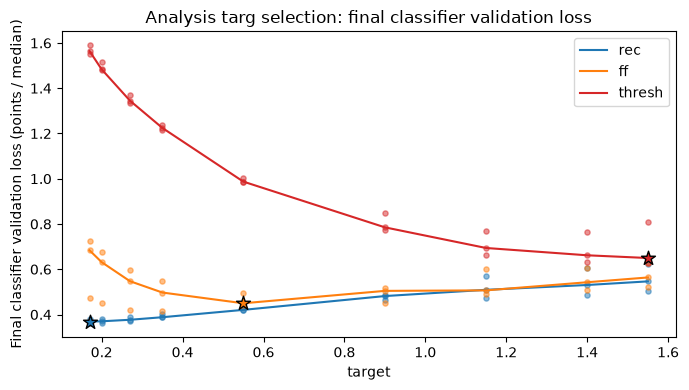

In [18]:
fig, ax = plt.subplots(figsize=FIGSIZE)
data = tables["target_evidence"]
for model in models:
    g = data[data.model_code == model]
    _points(ax, g, "targ", "final_val_loss", label=model, color=COLORS[model])
    value = g.loc[g.targ == targets[model], "final_val_loss"].median()
    ax.scatter(targets[model], value, marker="*", s=110, color=COLORS[model], edgecolors="black", zorder=4)
ax.set(title="Analysis targ selection: final classifier validation loss",
       xlabel="target", ylabel="Final classifier validation loss (points / median)")
ax.legend()
figures["G1_target_evidence"] = fig

figures['G1_target_evidence'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [19]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'targets_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G1_target_evidence'], ['hp_used_eta', 'target_evidence', 'target_statistics', 'target_candidate_evidence', 'target_diagnostic_candidates', 'analysis_targets', 'conditions', 'coverage'])

## 5. All-target response

S and final test accuracy are shown together for every trained target. They do not replace the target-selection criterion.

In [20]:
parts = [saved["entropy"].assign(**_identity(path, conditions))
         for path, (conditions, arrays, saved) in runs.items() if "entropy" in saved]
tables["entropy"] = pd.concat(parts, ignore_index=True)

In [21]:
for name in ['target_evidence']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

target_evidence: 81 rows (preview below; export keeps every row)


,best_val_accuracy,final_val_accuracy,final_test_accuracy,final_test_accuracy_full,n_features,n_classes,final_val_loss,final_step,final_cumulative_l1,run,...,targ,eta,seed_index,n_readout_parameters,final_model,readout_eval_every,readout_epochs,epoch,composite,silhouette
0,0.849609,0.849609,0.852539,0.8492,484,10,0.724346,240,690.707160,[local path],...,0.17,0.0003,0,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.000350,0.050741
1,0.889648,0.889648,0.881836,0.8822,484,10,0.472116,240,698.276295,[local path],...,0.17,0.0003,1,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.000361,0.086881
2,0.855469,0.851562,0.865234,0.8447,484,10,0.683691,240,657.068289,[local path],...,0.17,0.0003,2,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.001192,0.052187
3,0.874023,0.869141,0.877930,0.8730,484,10,0.597566,240,631.280215,[local path],...,0.27,0.0001,0,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.000415,0.049491
4,0.891602,0.891602,0.881836,0.8852,484,10,0.421395,240,623.988124,[local path],...,0.27,0.0001,1,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.000654,0.093082
5,0.875000,0.871094,0.871094,0.8644,484,10,0.547187,240,601.291007,[local path],...,0.27,0.0001,2,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.001681,0.046998
6,0.860352,0.858398,0.861328,0.8601,484,10,0.675552,240,670.852553,[local path],...,0.20,0.0003,0,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.000382,0.050697
7,0.892578,0.888672,0.876953,0.8840,484,10,0.449294,240,670.949394,[local path],...,0.20,0.0003,1,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.000448,0.089427
8,0.865234,0.860352,0.872070,0.8531,484,10,0.631357,240,639.323194,[local path],...,0.20,0.0003,2,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.001338,0.050510
9,0.879883,0.875977,0.875977,0.8781,484,10,0.546541,240,594.510985,[local path],...,0.35,0.0001,0,4850,last_step; best_val_accuracy is monitoring_only,1,15,9,0.000476,0.047283


### S and classifier response



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [22]:
FIGSIZE = (14, 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

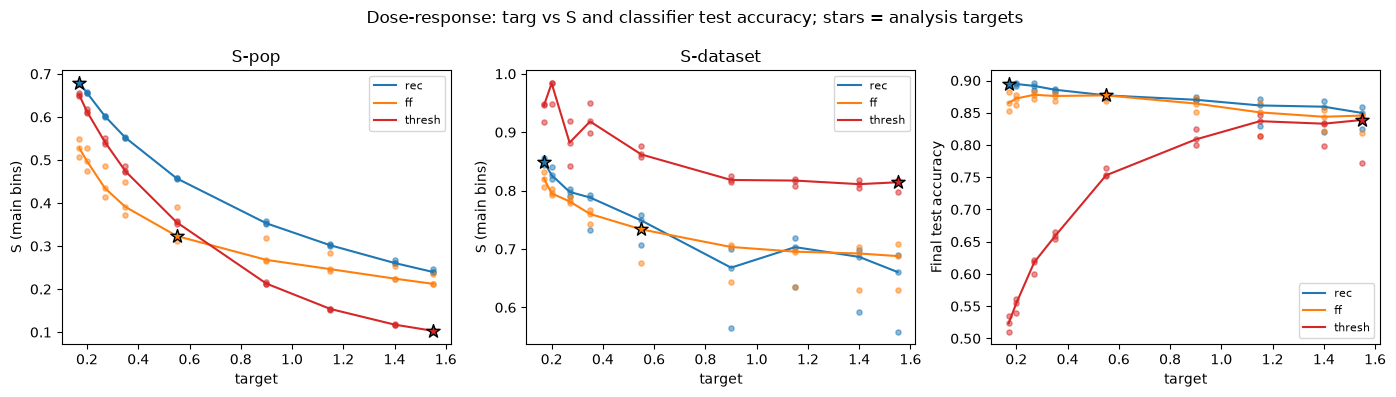

In [23]:
fig, axs = plt.subplots(1, 3, figsize=FIGSIZE)
# The saved "lifetime" axis is displayed as S-dataset.
for ax, axis, title in zip(axs[:2], ("population", "lifetime"), ("S-pop", "S-dataset")):
    e = tables["entropy"]
    for model in models:
        g = e[(e.arm == f"{model}_trained") & (e.axis == axis)]
        _points(ax, g, "targ", "S", label=model, color=COLORS[model])
        ax.scatter(targets[model], g.loc[g.targ == targets[model], "S"].median(),
                   marker="*", s=100, color=COLORS[model], edgecolors="black", zorder=4)
    ax.set(title=title, xlabel="target", ylabel="S (main bins)")
    ax.legend(fontsize=8)
for model in models:
    g = tables["summary"][tables["summary"].arm == f"{model}_trained"]
    _points(axs[2], g, "targ", "final_test_accuracy", label=model, color=COLORS[model])
    axs[2].scatter(targets[model], g.loc[g.targ == targets[model], "final_test_accuracy"].median(),
                   marker="*", s=100, color=COLORS[model], edgecolors="black", zorder=4)
axs[2].set(xlabel="target", ylabel="Final test accuracy")
axs[2].legend(fontsize=8)
fig.suptitle("Dose-response: targ vs S and classifier test accuracy; stars = analysis targets")
figures["G3_G4_target_response"] = fig

figures['G3_G4_target_response'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [24]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'response_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G3_G4_target_response'], ['target_evidence'])

## Export all figures and tables in this notebook

Run all main chapters first. Set `SAVE_NUMBERS=True` in Settings and choose
a new `EXPORT_NAME`. This saves the CSVs listed in `OWNED_TABLES`, prepared
main-chapter figures in the enabled formats, input/HP/population hashes,
effective targets, a notebook copy, and export settings.

Chapter exports must use different names. Save the notebook file before
exporting; after style changes, rerun the drawing cells and use a new name.

Optional saved-parameter inference and fixed-point checks are implemented in
[02_adaptation.ipynb](02_adaptation.ipynb). Optional UMAP fits are implemented
in [05_geometry.ipynb](05_geometry.ipynb). Each has its own computation switch
and can redraw from saved additional numbers.

In [25]:
print("Tables owned by this notebook:", OWNED_TABLES)
print("Figures prepared:", list(figures))
if SAVE_NUMBERS:
    export_section(EXPORT_NAME, list(figures), OWNED_TABLES)
else:
    print("Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.")

Tables owned by this notebook: ['hp_curves', 'hp_landscape', 'hp_selected', 'hp_used_eta', 'target_evidence', 'target_statistics', 'target_candidate_evidence', 'target_diagnostic_candidates', 'analysis_targets', 'conditions', 'coverage']
Figures prepared: ['G1_eta_landscape', 'G1_target_evidence', 'G3_G4_target_response']
Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.
